# Runs all Tox21 experiments with the full dataset!

1 output tasks 
Tox21 AUC-ROC KernelSVM: 0.822 GC: 0.829


Regression, 1,000 ish compounds, Random split, RMSE

CM and CM eigh require 3D structure - i don't think we need to run these anyways

rdkit featurisation does not work with classifier and i have no idea why - I think I need to add in a normalising transformer for that data!

Weave doesnt have a classification mode

Smiles to images + chemception does not work, but it should

Use tdaf-tf2p7h2             C:\Users\ella_\.conda\envs\tdaf-tf2p7h2

In [1]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc
#from deepchem.feat import SmilesToImage

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
#from projection.molecule import Molecule
#from projection.pdbmolecule import PDBMolecule
#from projection.mol2molecule import Mol2Molecule

import helper_functions as h
loaders, classification_datasets, regression_datasets, metric_types = h.deepchem_dataset_dictionaries()

# change THIS

dataset_name='tox21'

data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\d_" + dataset_name
test_file=dataset_name + '.csv'
data_file_name=dataset_name + '_topological_features.hdf5'
loader = loaders[dataset_name]
make_dataset=False # whether to recalc the dataset

print(f"DeepChem version: {dc.__version__}")

############################### settings for all experiments #################

#Tox21 AUC-ROC KernelSVM: 0.822 GC: 0.829
best_con = 0.822
best_graph = 0.829

num_repeats= 3
num_epochs = 2


metric1 = dc.metrics.Metric(dc.metrics.balanced_accuracy_score)
metric2 = dc.metrics.Metric(dc.metrics.prc_auc_score)
metric3 = dc.metrics.Metric(dc.metrics.roc_auc_score)
metric4 = dc.metrics.Metric(dc.metrics.f1_score)
#metric3 = dc.metrics.Metric(dc.metrics.mae_score)
metrics = [metric1, metric2, metric3, metric4]
selected_metric = 2 #which metric to use for callback
metric_selector=selected_metric
metric_labels = ['balanced_accuracy_score',
                 'prc_auc_score',
                 'roc_auc_score',
                 'f1_score']
#'roc_auc_score': 0.7074633658540642, 'f1_score': 0.343048783618714
Splitter = dc.splits.RandomSplitter()

# setting up the splitters for the task
#Splitter_Object_tf = dc.splits.SingletaskStratifiedSplitter()
#Splitter_Object_pca = dc.splits.SingletaskStratifiedSplitter()

split_fraction=[0.1, 0.1, 0.8]
n_classes=2


TensorFlow version: 2.7.0
DeepChem version: 2.5.0


In [ ]:
hdf5_file_name=dataset_name + '_topological_features.hdf5'
fh = h5py.File(os.path.join(data_dir,hdf5_file_name), 'r+')
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

In [ ]:
fh.keys()

In [2]:
tasks, datasets, transformers = loader(
            shard_size=2000,
            splitter=None)

In [3]:
datasets[0].tasks

array(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER',
       'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE',
       'SR-MMP', 'SR-p53'], dtype='<U13')

In [5]:
transformers

In [ ]:
feature_name_list = ['pers_S_1', 'pers_S_2', 'pers_S_3',
                    'no_p_1', 'no_p_2', 'no_p_3',
                    'bottle_1', 'bottle_2', 'bottle_3',
                    'wasser_1', 'wasser_2', 'wasser_3',
                    'landsc_1', 'landsc_2', 'landsc_3',
                    'pers_img_1', 'pers_img_2', 'pers_img_3']

PCA_list = ['PCA_1', 'PCA_2', 'PCA_3',
           'PCA_4', 'PCA_5', 'PCA_6',
           'PCA_7', 'PCA_8', 'PCA_9',
           'PCA_10', 'PCA_11', 'PCA_12',
           'PCA_13', 'PCA_14', 'PCA_15',
           'PCA_16', 'PCA_17', 'PCA_18']

task_list = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER',
       'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE',
       'SR-MMP', 'SR-p53']

## Functions

In [92]:
test_dataset

<DiskDataset X.shape: (6265, 1024), y.shape: (6265, 12), w.shape: (6265, 12), task_names: ['NR-AR' 'NR-AR-LBD' 'NR-AhR' ... 'SR-HSE' 'SR-MMP' 'SR-p53']>

# Load data


## Create topological datasets

We use Numpy datasets to create the two toplogical datasets and two transformers (used as the controls use them and they are supposed to improve training). The topological dataset is normalised in X and y, PCA is only normalised in y as PCA is a normalisation.

This sorts out the datasets, transformers and splitters for the task

In [ ]:
fh['SMILES']

In [ ]:
## loading data from the hdf5 file
X_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=feature_name_list)

PCA_X_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=PCA_list)

y_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=task_list)

SMILES_list = np.array(fh['SMILES'])

# making the datasets
topol_dataset = dc.data.DiskDataset.from_numpy(
    X_data, 
    y_data, 
    ids=SMILES_list)

pca_dataset = dc.data.DiskDataset.from_numpy(
    PCA_X_data, 
    y_data, 
    ids=SMILES_list)

# doing a transform on the data to make it easier for hte NN
# both y and x
transformers_tf = [
    dc.trans.NormalizationTransformer(
        transform_X=True, 
        dataset=topol_dataset),
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=topol_dataset)]
# only y
transformers_pca = [
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=pca_dataset)]



In [ ]:
plt.hist(y_data)
plt.xlabel('Energies?')
plt.ylabel("No.")

# Training on the topological features

#### Topological features

In [ ]:
%%time
output_metrics_tf=h.topol_regression_experiment(
    dataset=topol_dataset,
    transformers=transformers_tf,
    Splitter_Object=Splitter,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score', 
                   'mae_score', 
                   'rmse']
    )
output_metrics_tf

#### PCA of topological features

In [ ]:
%%time
output_metrics_pca=h.topol_regression_experiment(
    dataset=pca_dataset,
    transformers=transformers_pca,
    Splitter_Object=Splitter,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca

#### PCA of topological features with no transform

In [ ]:
%%time
output_metrics_pca_no_transform=h.no_transform_topol_regression_experiment(
    dataset=pca_dataset,
    Splitter_Object=Splitter,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca_no_transform

## 1-D inputs

#### ECFP

In [28]:
%%time
output_metrics_ecfp = h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='ECFP',
        loader=loader,
        model_setting='MTC',
        dimension=1,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)

output_metrics_ecfp

Metric selected is roc_auc_score
Using dataset selector setting ECFP
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using multitask classifier model
Step 15 validation: roc_auc_score=0.707277
Using dataset selector setting ECFP
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using multitask classifier model
Step 15 validation: roc_auc_score=0.668118
Using dataset selector setting ECFP
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using multitask classifier model
Step 15 validation: roc_auc_score=0.66858
Wall time: 5.4 s


,tr_bal_acc,tr_prc_auc,tr_roc_auc,tr_f1,val_bal_acc,val_prc_auc,val_roc_auc,val_f1,te_bal_acc,te_prc_auc,te_roc_auc,te_f1
0,0.757132,0.718100,0.954338,0.431720,0.608606,0.246528,0.708597,0.216341,0.590136,0.216417,0.666879,0.206453
1,0.743874,0.721776,0.947613,0.428915,0.573471,0.188497,0.670654,0.178037,0.591480,0.214127,0.679849,0.222555
2,0.729770,0.716605,0.950581,0.527338,0.563171,0.228033,0.670030,0.179423,0.561956,0.199290,0.673737,0.171165


### rdkit features

In [12]:
featurizer_rdkit = dc.feat.RDKitDescriptors()
tasks, datasets, transformers = loader(
            shard_size=2000,
            featurizer=featurizer_rdkit)

In [18]:
datasets[2]

<DiskDataset X.shape: (784, 208), y.shape: (784, 12), w.shape: (784, 12), ids: ['CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O.CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O.c1ccc(CNCCNCc2ccccc2)cc1'
 'CC(C)(c1ccc(Oc2ccc3c(c2)C(=O)OC3=O)cc1)c1ccc(Oc2ccc3c(c2)C(=O)OC3=O)cc1'
 'Cc1cc(C(C)(C)C)c(O)c(C)c1Cn1c(=O)n(Cc2c(C)cc(C(C)(C)C)c(O)c2C)c(=O)n(Cc2c(C)cc(C(C)(C)C)c(O)c2C)c1=O'
 ... 'CN[C@@H]1C[C@@H](c2ccc(Cl)c(Cl)c2)c2ccccc21'
 'Cl/C=C\\C[N+]12CN3CN(CN(C3)C1)C2'
 'NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)([O-])OP(=O)(O)OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](O)[C@@H]3O)[C@@H](O)[C@H]2O)c1'], task_names: ['NR-AR' 'NR-AR-LBD' 'NR-AhR' ... 'SR-HSE' 'SR-MMP' 'SR-p53']>

In [16]:
model = dc.models.MultitaskClassifier(
            n_tasks=12,
            n_features=208,
            # layer_sizes=[1000,1000,500,20],
            dropouts=0.2,
            # learning_rate=0.001,
            residual=True)

In [20]:
model.fit(datasets[2], nb_epoch=2)

nan

In [5]:
%%time
output_metrics_rdkit = h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='rdkit',
        loader=loader,
        model_setting='MTC',
        dimension=1,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)

output_metrics_rdkit

Metric selected is roc_auc_score
Using dataset selector setting rdkit
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using multitask classifier model


ValueError: Input contains NaN, infinity or a value too large for dtype('float32').

ValueError: supplied range of [-83.82610530607127, inf] is not finite

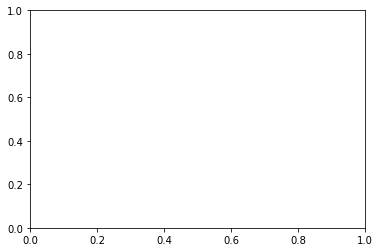

In [26]:
plt.hist(datasets[0].X)


## MACCS features

In [29]:
%%time
output_metrics_maccs = h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='MACCS',
        loader=loader,
        model_setting='MTC',
        dimension=1,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)

output_metrics_maccs

Metric selected is roc_auc_score
Using dataset selector setting MACCS
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using multitask classifier model
Step 15 validation: roc_auc_score=0.673516
Using dataset selector setting MACCS
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using multitask classifier model
Step 15 validation: roc_auc_score=0.711778
Using dataset selector setting MACCS
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using multitask classifier model
Step 15 validation: roc_auc_score=0.700735
Wall time: 3.47 s


,tr_bal_acc,tr_prc_auc,tr_roc_auc,tr_f1,val_bal_acc,val_prc_auc,val_roc_auc,val_f1,te_bal_acc,te_prc_auc,te_roc_auc,te_f1
0,0.658045,0.290011,0.811258,0.207552,0.602532,0.183733,0.676430,0.150139,0.612393,0.195134,0.683875,0.161641
1,0.657995,0.328295,0.822073,0.197670,0.588529,0.221914,0.713392,0.158507,0.576312,0.174948,0.678333,0.149467
2,0.663870,0.360291,0.811465,0.198667,0.603941,0.212316,0.700874,0.148732,0.610197,0.202076,0.701654,0.151046


### graph for 1D features

In [ ]:


data=[output_metrics_ecfp['tr_mae'],
     output_metrics_ecfp['te_mae'],
     output_metrics_maccs['tr_mae'],
     output_metrics_maccs['te_mae'],
     output_metrics_rdkit['tr_mae'],
     output_metrics_rdkit['te_mae'],
     output_metrics_cm_eig['tr_mae'],
     output_metrics_cm_eig['te_mae'],
     output_metrics_tf['tr_mae'],
     output_metrics_tf['te_mae'],
     output_metrics_pca['tr_mae'],
     output_metrics_pca['te_mae']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200",
               "#5f77f4","#f62788",
               "#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

axes=plt.gca()
#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5]
plt.xticks(x_tick_list,['ECFP',"MACCS","rdkit","CM_eig","TDAF","PCA-TDAF"])
plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='-.')
#plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='-.')

plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(dataset_name + "1Donly.png"))

## 2D inputs and graph models

In [34]:
%%time
output_metrics_Sm2Img=h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='Smiles2Img',
        loader=loader,
        model_setting='ChemCeption',
        dimension=2,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)



output_metrics_Sm2Img.head(3)

Metric selected is roc_auc_score
Using dataset selector setting Smiles2Img
!!!!Make this function new for each new dataset!!!!
Training with 778 points
Validation with 778 points
Testing with 6224 points
Total dataset size: 7780
Step 15 validation: roc_auc_score=0.510414


ValueError: y must be a class probability matrix with rows summing to 1.

In [31]:
%%time
output_metrics_gc=h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='ConvMol',
        loader=loader,
        model_setting='GraphConv',
        dimension=2,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)

output_metrics_gc.head(3)

Metric selected is roc_auc_score
Using dataset selector setting ConvMol
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using GraphConvMol model


C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_14:0", shape=(513,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_13:0", shape=(513, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_17:0", shape=(1756,), dtype=int32), values=Tensor("gradient_tape/private__gr

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_14:0", shape=(433,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_13:0", shape=(433, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_17:0", shape=(1692,), dtype=int32), values=Tensor("gradient_tape/private__gr

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_conv_1/Reshape_11:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model/graph_conv_1/Reshape_10:0", shape=(None, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model/graph_conv_1/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_conv_1/Reshape_13:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/private__gr

Step 15 validation: roc_auc_score=0.547288
Using dataset selector setting ConvMol
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using GraphConvMol model


...

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_14:0", shape=(476,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_13:0", shape=(476, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_17:0", shape=(1802,), dtype=int32), values=Tensor("gradient_tape/pri

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_14:0", shape=(450,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_13:0", shape=(450, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_17:0", shape=(1818,), dtype=int32), values=Tensor("gradient_tape/pri

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_conv_5/Reshape_11:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_conv_5/Reshape_10:0", shape=(None, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_conv_5/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_conv_5/Reshape_13:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/pri

Step 15 validation: roc_auc_score=0.548712
Wall time: 51.4 s


,tr_bal_acc,tr_prc_auc,tr_roc_auc,tr_f1,val_bal_acc,val_prc_auc,val_roc_auc,val_f1,te_bal_acc,te_prc_auc,te_roc_auc,te_f1
0,0.514519,0.086600,0.577940,0.089893,0.516142,0.083336,0.550511,0.092778,0.512026,0.075675,0.538434,0.088100
1,0.557395,0.127192,0.640503,0.136969,0.531212,0.086641,0.559040,0.088350,0.539964,0.091486,0.597921,0.106948
2,0.537519,0.089781,0.610976,0.110826,0.506798,0.072468,0.550412,0.093513,0.526557,0.082279,0.564636,0.107908


In [32]:
%%time
output_metrics_weave=h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='Weave',
        loader=loader,
        model_setting='Weave',
        dimension=2,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)

output_metrics_weave.head(3)

Metric selected is roc_auc_score
Using dataset selector setting Weave
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using Weave model
Step 15 validation: roc_auc_score=0.624176
Using dataset selector setting Weave
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using Weave model
Step 15 validation: roc_auc_score=0.514501
Using dataset selector setting Weave
!!!!Make this function new for each new dataset!!!!
Training with 783 points
Validation with 783 points
Testing with 6265 points
Total dataset size: 7831
Using Weave model
Step 15 validation: roc_auc_score=0.598273
Wall time: 1min 20s


,tr_bal_acc,tr_prc_auc,tr_roc_auc,tr_f1,val_bal_acc,val_prc_auc,val_roc_auc,val_f1,te_bal_acc,te_prc_auc,te_roc_auc,te_f1
0,0.507253,0.094245,0.607180,0.134695,0.502061,0.084737,0.626084,0.118042,0.504710,0.082935,0.629310,0.113753
1,0.507949,0.087267,0.553596,0.109297,0.500300,0.063431,0.519162,0.090750,0.500402,0.075906,0.539057,0.101428
2,0.509942,0.092647,0.626270,0.103967,0.510394,0.087979,0.603443,0.102038,0.510783,0.085641,0.598762,0.104716


## Write out data and graphs

In [35]:
list_of_data_frames=[output_metrics_ecfp,
    output_metrics_maccs,
    #output_metrics_rdkit,
    #output_metrics_cm_eig,
    #output_metrics_Sm2Img,
    output_metrics_gc,
    output_metrics_weave
    #output_metrics_cm,
    #output_metrics_tf,
    #output_metrics_pca
                    ]

list_of_data_frames_names=["output_metrics_ecfp",
    "output_metrics_maccs",
    #"output_metrics_rdkit",
    #"output_metrics_cm_eig",
    #"output_metrics_Sm2Img",
    "output_metrics_gc",
    "output_metrics_weave"
    #"output_metrics_cm",
    #"output_metrics_tf",
    #"output_metrics_pca"
                          ]

In [37]:
for i in range(len(list_of_data_frames)):
    list_of_data_frames[i].to_csv(os.path.join(
        results_dir, 
        list_of_data_frames_names[i] + '.csv'))


ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of ticklabels (6).

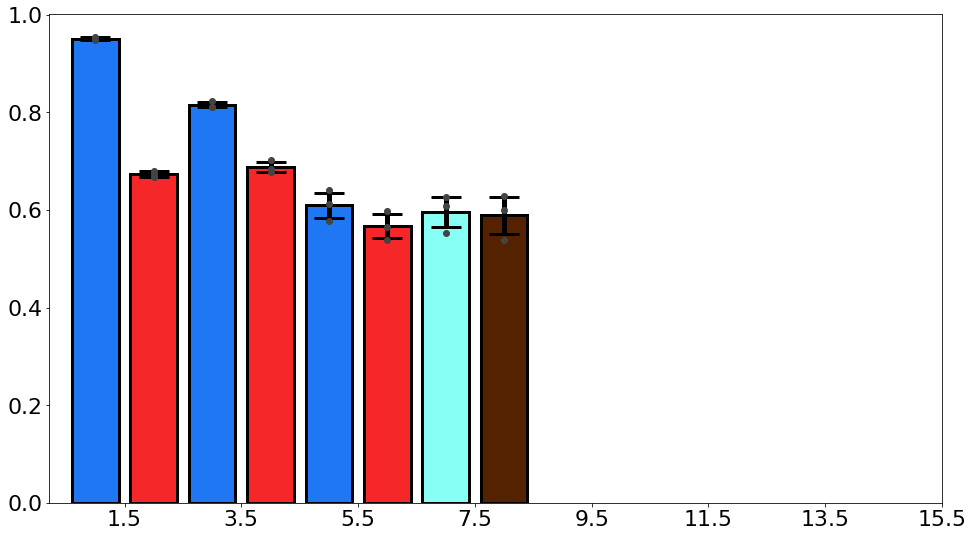

In [40]:
#Best=1.92
#'tr_roc_auc'

data=[output_metrics_ecfp['tr_roc_auc'],
     output_metrics_ecfp['te_roc_auc'],
     output_metrics_maccs['tr_roc_auc'],
     output_metrics_maccs['te_roc_auc'],
     #output_metrics_rdkit['tr_roc_auc'],
     #output_metrics_rdkit['te_roc_auc'],
     #output_metrics_cm_eig['tr_mae'],
     #output_metrics_cm_eig['te_mae'],
     #output_metrics_Sm2Img['tr_roc_auc'],
     #output_metrics_Sm2Img['te_roc_auc'],
     output_metrics_gc['tr_roc_auc'],
     output_metrics_gc['te_roc_auc'],
     output_metrics_weave['tr_roc_auc'],
     output_metrics_weave['te_roc_auc']]
     #output_metrics_cm['tr_mae'],
     #output_metrics_cm['te_mae']]
     #output_metrics_tf['tr_mae'],
     #output_metrics_tf['te_mae'],
     #output_metrics_pca['tr_mae'],
     #output_metrics_pca['te_mae']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728", # red blue
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200", #brown green
               "#61ff33","#ffb433", # green orange
               "#61ff33","#ffb433",
               "#61ff33","#ffb433",               
               "#88fff4","#552200"], #brown green               
               #"#5f77f4","#f62788", # pink blue
               #"#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")


#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5,13.5,15.5]
plt.xticks(x_tick_list,
           ['ECFP',"MACCS","rdkit",
            'Sm2Img', 'GC', 'Weave'], rotation=45)
plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='-.')
plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='-.')

axes=plt.gca()
plt.ylabel('RMSE kcal/mol')
plt.savefig(os.path.join(results_dir, dataset_name + "control_data.png"))

In [ ]:
#Best=1.92

data=[output_metrics_ecfp['tr_mae'],
     output_metrics_ecfp['te_mae'],
     output_metrics_maccs['tr_mae'],
     output_metrics_maccs['te_mae'],
     output_metrics_rdkit['tr_mae'],
     output_metrics_rdkit['te_mae'],
     output_metrics_cm_eig['tr_mae'],
     output_metrics_cm_eig['te_mae'],
     output_metrics_Sm2Img['tr_mae'],
     output_metrics_Sm2Img['te_mae'],
     output_metrics_gc['tr_mae'],
     output_metrics_gc['te_mae'],
     output_metrics_weave['tr_mae'],
     output_metrics_weave['te_mae'],
     output_metrics_cm['tr_mae'],
     output_metrics_cm['te_mae'],
     output_metrics_tf['tr_mae'],
     output_metrics_tf['te_mae'],
     output_metrics_pca['tr_mae'],
     output_metrics_pca['te_mae']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728", # red blue
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200", #brown green
               "#61ff33","#ffb433", # green orange
               "#61ff33","#ffb433",
               "#61ff33","#ffb433",               
               "#88fff4","#552200", #brown green               
               "#5f77f4","#f62788", # pink blue
               "#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")


#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5,13.5,15.5,17.5,19.5]
plt.xticks(x_tick_list,
           ['ECFP',"MACCS","rdkit","CM_eig",
            'Sm2Img', 'GC', 'Weave', 'CM',
            "TDAF","PCA-TDAF"], roation=45)
plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='-.')
plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='-.')

axes=plt.gca()
plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(results_dir, dataset_name + "all_data.png"))

## stats stuff

import scipy
scipy.stats.ttest_ind(test_scores_CM_eig, test_scores_pca, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

In [ ]:
fh.close()